In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('ipl.csv')

In [3]:
data.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [4]:
data.shape

(76014, 15)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [6]:
data.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [7]:
data.sample(2)

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
67890,552,2016-05-21,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Kings XI Punjab,Rising Pune Supergiants,M Vijay,AB Dinda,25,0,3.6,25,0,16,8,172
40772,331,2013-04-15,"MA Chidambaram Stadium, Chepauk",Pune Warriors,Chennai Super Kings,AJ Finch,RA Jadeja,32,0,3.6,32,0,27,3,159


In [8]:
data.drop(columns=[ 'mid','venue', 'batsman', 'bowler', 'striker', 'non-striker'],inplace=True)

In [9]:
data.sample(2)

,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
68897,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,54,1,5.4,48,1,207
52314,2014-05-13,Rajasthan Royals,Chennai Super Kings,54,0,7.3,39,0,148


In [10]:
print(data['bat_team'].nunique())
data['bat_team'].value_counts()

14


Mumbai Indians                 10213
Kings XI Punjab                 9219
Chennai Super Kings             9142
Royal Challengers Bangalore     8331
Kolkata Knight Riders           8033
Delhi Daredevils                7152
Rajasthan Royals                6643
Deccan Chargers                 5280
Sunrisers Hyderabad             5216
Pune Warriors                   2448
Gujarat Lions                   1726
Rising Pune Supergiant           994
Kochi Tuskers Kerala             876
Rising Pune Supergiants          741
Name: bat_team, dtype: int64

In [11]:
print(data['bowl_team'].nunique())
data['bowl_team'].value_counts()

14


Delhi Daredevils               10245
Royal Challengers Bangalore     9661
Mumbai Indians                  9271
Kolkata Knight Riders           9211
Kings XI Punjab                 8405
Rajasthan Royals                7773
Chennai Super Kings             6497
Deccan Chargers                 3984
Sunrisers Hyderabad             3589
Pune Warriors                   3083
Gujarat Lions                   1970
Rising Pune Supergiant           962
Kochi Tuskers Kerala             736
Rising Pune Supergiants          627
Name: bowl_team, dtype: int64

In [12]:
#the teams in ipl now
teams = ['Sunrisers Hyderabad',
    'Mumbai Indians',
    'Gujarat Titans',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals',
    'Lucknow Super Giants']

In [13]:
# Replace Delhi Daredevils with Delhi capitals
data['bat_team'] = data['bat_team'].str.replace('Delhi Daredevils', 'Delhi Capitals')
data['bowl_team'] = data['bowl_team'].str.replace('Delhi Daredevils', 'Delhi Capitals')

#Replace 'Deccan Chargers' with 'Sunrisers Hyderabad'
data['bat_team'] = data['bat_team'].str.replace('Deccan Chargers', 'Sunrisers Hyderabad')
data['bowl_team'] = data['bowl_team'].str.replace('Deccan Chargers', 'Sunrisers Hyderabad')

#Replace 'Gujarat Lions' with 'Gujarat Titans'
data['bat_team'] = data['bat_team'].str.replace('Gujarat Lions', 'Gujarat Titans')
data['bowl_team'] = data['bowl_team'].str.replace('Gujarat Lions', 'Gujarat Titans')

In [14]:
data = data[data['bat_team'].isin(teams)]
data = data[data['bowl_team'].isin(teams)]

In [15]:
data['bowl_team'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Mumbai Indians',
       'Chennai Super Kings', 'Sunrisers Hyderabad', 'Gujarat Titans'],
      dtype=object)

In [16]:
data=data[data['overs']>=5.0]

In [17]:
data.head(2)

,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222
33,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222


In [18]:
data.columns

Index(['date', 'bat_team', 'bowl_team', 'runs', 'wickets', 'overs',
       'runs_last_5', 'wickets_last_5', 'total'],
      dtype='object')

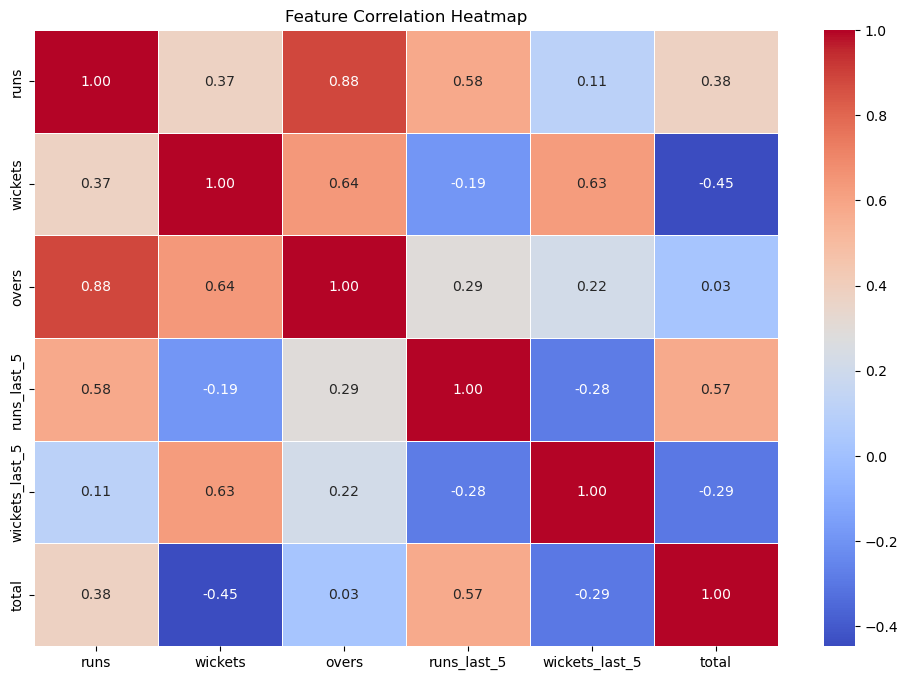

In [19]:
numerical_features = data.select_dtypes(include=[np.number])


correlation_matrix = numerical_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
data['date'] = pd.to_datetime(data['date'])

In [21]:
data['year']=data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

In [22]:
data['year'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017],
      dtype=int64)

In [23]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [24]:
data['run_rate'] = data['runs'] / data['overs'].replace(0, np.nan) 
data['balls_remaining'] = (20 - data['overs']) * 6
data['wickets_remaining'] = 10 - data['wickets']

In [25]:
data['run_rate_last_5'] = data['runs_last_5'] / 5
data['wicket_rate_last_5'] = data['wickets_last_5'] / 5

data.drop(columns=['runs_last_5','wickets_last_5'])

,date,bat_team,bowl_team,runs,wickets,overs,total,year,month,day,run_rate,balls_remaining,wickets_remaining,run_rate_last_5,wicket_rate_last_5
32,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,222,2008,4,18,11.960784,89.4,10,11.8,0.0
33,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,222,2008,4,18,11.730769,88.8,9,11.8,0.2
34,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,222,2008,4,18,11.509434,88.2,9,11.8,0.2
35,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,222,2008,4,18,11.296296,87.6,9,11.8,0.2
36,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,222,2008,4,18,11.090909,87.0,9,11.6,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75884,2017-05-19,Kolkata Knight Riders,Mumbai Indians,106,9,18.1,107,2017,5,19,5.856354,11.4,1,5.8,0.8
75885,2017-05-19,Kolkata Knight Riders,Mumbai Indians,107,9,18.2,107,2017,5,19,5.879121,10.8,1,5.8,0.8
75886,2017-05-19,Kolkata Knight Riders,Mumbai Indians,107,9,18.3,107,2017,5,19,5.846995,10.2,1,5.6,0.8
75887,2017-05-19,Kolkata Knight Riders,Mumbai Indians,107,9,18.4,107,2017,5,19,5.815217,9.6,1,4.8,0.8


In [26]:
data.isnull().sum()

date                  0
bat_team              0
bowl_team             0
runs                  0
wickets               0
overs                 0
runs_last_5           0
wickets_last_5        0
total                 0
year                  0
month                 0
day                   0
run_rate              0
balls_remaining       0
wickets_remaining     0
run_rate_last_5       0
wicket_rate_last_5    0
dtype: int64

In [27]:
cat_features = ['bat_team','bowl_team']
num_features = [col for col in data.columns if col not in ['bat_team', 'bowl_team', 'date']]
scalar_data=data[num_features]
scalar_data

,runs,wickets,overs,runs_last_5,wickets_last_5,total,year,month,day,run_rate,balls_remaining,wickets_remaining,run_rate_last_5,wicket_rate_last_5
32,61,0,5.1,59,0,222,2008,4,18,11.960784,89.4,10,11.8,0.0
33,61,1,5.2,59,1,222,2008,4,18,11.730769,88.8,9,11.8,0.2
34,61,1,5.3,59,1,222,2008,4,18,11.509434,88.2,9,11.8,0.2
35,61,1,5.4,59,1,222,2008,4,18,11.296296,87.6,9,11.8,0.2
36,61,1,5.5,58,1,222,2008,4,18,11.090909,87.0,9,11.6,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75884,106,9,18.1,29,4,107,2017,5,19,5.856354,11.4,1,5.8,0.8
75885,107,9,18.2,29,4,107,2017,5,19,5.879121,10.8,1,5.8,0.8
75886,107,9,18.3,28,4,107,2017,5,19,5.846995,10.2,1,5.6,0.8
75887,107,9,18.4,24,4,107,2017,5,19,5.815217,9.6,1,4.8,0.8


In [28]:
from sklearn.preprocessing import OneHotEncoder
cat_data = data[cat_features]

ohe = OneHotEncoder(sparse=False, handle_unknown='ignore', drop='first') 

encoded_array = ohe.fit_transform(cat_data)

feature_names = ohe.get_feature_names_out(cat_features)

encoded_data = pd.DataFrame(encoded_array, columns=feature_names)

In [29]:
print("Encoded data nulls:", encoded_data.isnull().sum().sum())
print("Scalar data nulls:", scalar_data.isnull().sum().sum())

Encoded data nulls: 0
Scalar data nulls: 0


In [30]:
encoded_data = encoded_data.reset_index(drop=True)
scalar_data = scalar_data.reset_index(drop=True)

final_data = pd.concat([encoded_data, scalar_data,], axis=1)

In [31]:
final_data

,bat_team_Delhi Capitals,bat_team_Gujarat Titans,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Rajasthan Royals,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Delhi Capitals,bowl_team_Gujarat Titans,...,wickets_last_5,total,year,month,day,run_rate,balls_remaining,wickets_remaining,run_rate_last_5,wicket_rate_last_5
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,222,2008,4,18,11.960784,89.4,10,11.8,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,222,2008,4,18,11.730769,88.8,9,11.8,0.2
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,222,2008,4,18,11.509434,88.2,9,11.8,0.2
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,222,2008,4,18,11.296296,87.6,9,11.8,0.2
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,222,2008,4,18,11.090909,87.0,9,11.6,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48959,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4,107,2017,5,19,5.856354,11.4,1,5.8,0.8
48960,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4,107,2017,5,19,5.879121,10.8,1,5.8,0.8
48961,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4,107,2017,5,19,5.846995,10.2,1,5.6,0.8
48962,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4,107,2017,5,19,5.815217,9.6,1,4.8,0.8


In [32]:
x = final_data.drop(['total'], axis=1)
y = final_data['total']

x_train = x[x['year']<= 2016]
x_test = x[x['year'] == 2017]
y_train = y[x['year'] <= 2016]
y_test = y[x['year'] == 2017]

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

In [34]:
x_train

,bat_team_Delhi Capitals,bat_team_Gujarat Titans,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Rajasthan Royals,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Delhi Capitals,bowl_team_Gujarat Titans,...,runs_last_5,wickets_last_5,year,month,day,run_rate,balls_remaining,wickets_remaining,run_rate_last_5,wicket_rate_last_5
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59,0,2008,4,18,11.960784,89.4,10,11.8,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59,1,2008,4,18,11.730769,88.8,9,11.8,0.2
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59,1,2008,4,18,11.509434,88.2,9,11.8,0.2
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59,1,2008,4,18,11.296296,87.6,9,11.8,0.2
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58,1,2008,4,18,11.090909,87.0,9,11.6,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,54,4,2016,5,29,10.104167,4.8,3,10.8,0.8
45080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,56,4,2016,5,29,10.362694,4.2,3,11.2,0.8
45081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,56,4,2016,5,29,10.360825,3.6,3,11.2,0.8
45082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,57,4,2016,5,29,10.358974,3.0,3,11.4,0.8


In [42]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'AdaBoost': AdaBoostRegressor(base_estimator=LinearRegression(), n_estimators=50)
}

for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    print(f"--- {name} ---")
    print("r2_score:", r2_score(y_test, preds))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("MSE:", mean_squared_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print()


--- Linear Regression ---
r2_score: 0.7217806301422413
MAE: 12.385160032851246
MSE: 257.3440838049776
RMSE: 16.041947631287716

--- Decision Tree ---
r2_score: 0.24017899115512065
MAE: 19.51443298969072
MSE: 702.8103092783505
RMSE: 26.510569765253074

--- Random Forest ---
r2_score: 0.5647781044676757
MAE: 14.35108762886598
MSE: 402.56643530927835
RMSE: 20.06405829609948

--- AdaBoost ---
r2_score: 0.7092272306302926
MAE: 12.866951359731635
MSE: 268.9555797899333
RMSE: 16.399865236944276



In [43]:
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [44]:
y_pred=lr.predict(x_test)
l=r2_score(y_test,y_pred)
l

0.7217806301422413

In [45]:
x_test

,bat_team_Delhi Capitals,bat_team_Gujarat Titans,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Rajasthan Royals,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Delhi Capitals,bowl_team_Gujarat Titans,...,runs_last_5,wickets_last_5,year,month,day,run_rate,balls_remaining,wickets_remaining,run_rate_last_5,wicket_rate_last_5
45084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,42,1,2017,4,5,9.019608,89.4,9,8.4,0.2
45085,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,46,1,2017,4,5,9.615385,88.8,9,9.2,0.2
45086,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,44,1,2017,4,5,9.433962,88.2,9,8.8,0.2
45087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,48,1,2017,4,5,10.000000,87.6,9,9.6,0.2
45088,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,51,1,2017,4,5,10.545455,87.0,9,10.2,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48959,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29,4,2017,5,19,5.856354,11.4,1,5.8,0.8
48960,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29,4,2017,5,19,5.879121,10.8,1,5.8,0.8
48961,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28,4,2017,5,19,5.846995,10.2,1,5.6,0.8
48962,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,24,4,2017,5,19,5.815217,9.6,1,4.8,0.8


In [46]:
def predict_score(
    bat_team, bowl_team,
    overs, runs, wickets,
    runs_last_5, wickets_last_5,
    date
):
    # Derived features
    run_rate = runs / overs
    balls_remaining = (20 - overs) * 6
    wickets_remaining = 10 - wickets
    date= pd.to_datetime(date)
    match_year=date.year
    month=date.month
    day=date.day
    run_rate_last_5 = runs_last_5/ 5
    wicket_rate_last_5 = wickets_last_5

    input_dict = {
        'runs': [runs],
        'wickets': [wickets],
        'overs': [overs],
        'runs_last_5': [runs_last_5],
        'wickets_last_5': [wickets_last_5],
        'month': [month],
        'day': [day],
        'run_rate': [run_rate],
        'balls_remaining': [balls_remaining],
        'wickets_remaining': [wickets_remaining],
        'year': [match_year],
        'run_rate_last_5':[run_rate_last_5],
        'wicket_rate_last_5':[wicket_rate_last_5]
        
        
    }

    input_df = pd.DataFrame(input_dict)

    team_df = pd.DataFrame([[bat_team, bowl_team]], columns=cat_features)
    encoded_cat_array = ohe.transform(team_df)
    encoded_cat_df = pd.DataFrame(encoded_cat_array, columns=ohe.get_feature_names_out(cat_features))

    final_input = pd.concat([encoded_cat_df.reset_index(drop=True), input_df.reset_index(drop=True)], axis=1)

    final_input = final_input.reindex(columns=x_train.columns, fill_value=0)

    prediction = lr.predict(final_input)[0]
    return round(prediction)


In [49]:
m=predict_score(
    bat_team='Sunrisers Hyderabad',
    bowl_team='Chennai Super Kings',
    overs=12.0,
    runs=95,
    wickets=3,
    runs_last_5=20,
    wickets_last_5=1,
    date='2019-04-18'
)
print("predicted_score:",m)


predicted_score: 168
